In [1]:
from src.data_loader import load_features, load_labels

X_train = load_features("data/X_train.txt")
y_train = load_labels("data/y_train.txt")

X_test = load_features("data/X_test.txt")
y_test = load_labels("data/y_test.txt")

In [2]:
X_train.shape

(7352, 561)

In [3]:
import pandas as pd
X = pd.concat([X_train, X_test], axis=0)
y = pd.concat([y_train, y_test], axis = 0)

In [4]:
X

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,0.074472,-0.376278,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784
2943,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,0.101859,-0.320418,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412
2944,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.066249,-0.118854,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184
2945,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,-0.289477,0.007471,...,-0.046467,-0.205445,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563


# DATA UNDERSTANDING

## feature strength

In [5]:
'''checking variance of data and vairance distribution'''

'checking variance of data and vairance distribution'

In [6]:
import numpy as np

features = X.columns.to_list()


In [7]:
variance = X.var()

variance_df = variance.to_frame(name = 'variance')

variance_df = variance_df.sort_values(by = 'variance')
print(variance_df.head())
print(variance_df.tail())

     variance
1    0.001379
2    0.002813
388  0.002872
478  0.003409
484  0.004187
     variance
78   0.495532
287  0.522666
234  0.524056
367  0.539207
366  0.561720


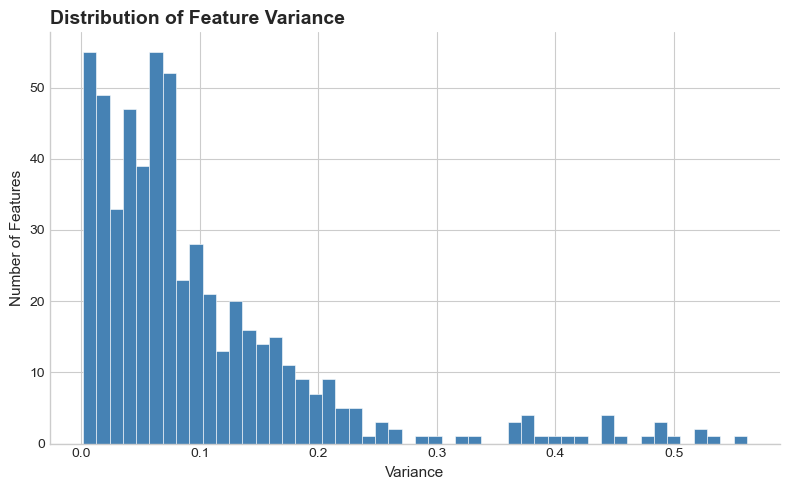

In [8]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(variance_df['variance'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel("Variance", fontsize=11)
ax.set_ylabel("Number of Features", fontsize=11)
ax.set_title("Distribution of Feature Variance", fontsize=14, fontweight='bold', loc='left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## feature redundancy

In [9]:
X.describe()

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
count,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,...,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000
mean,0.274347,-0.017743,-0.108925,-0.607784,-0.510191,-0.613064,-0.633593,-0.525697,-0.614989,-0.466732,...,0.126708,-0.298592,-0.617700,0.007705,0.002648,0.017683,-0.009219,-0.496522,0.063255,-0.054284
std,0.067628,0.037128,0.053033,0.438694,0.500240,0.403657,0.413333,0.484201,0.399034,0.538707,...,0.245443,0.320199,0.308796,0.336591,0.447364,0.616188,0.484770,0.511158,0.305468,0.268898
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.262625,-0.024902,-0.121019,-0.992360,-0.976990,-0.979137,-0.993293,-0.977017,-0.979064,-0.935788,...,-0.019481,-0.536174,-0.841847,-0.124694,-0.287031,-0.493108,-0.389041,-0.817288,0.002151,-0.131880
50%,0.277174,-0.017162,-0.108596,-0.943030,-0.835032,-0.850773,-0.948244,-0.843670,-0.845068,-0.874825,...,0.136245,-0.335160,-0.703402,0.008146,0.007668,0.017192,-0.007186,-0.715631,0.182028,-0.003882
75%,0.288354,-0.010625,-0.097589,-0.250293,-0.057336,-0.278737,-0.302033,-0.087405,-0.288149,-0.014641,...,0.288960,-0.113167,-0.487981,0.149005,0.291490,0.536137,0.365996,-0.521503,0.250790,0.102970
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


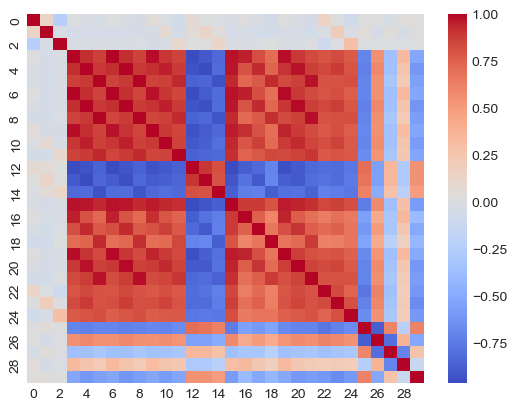

In [10]:
import seaborn as sns

sample_features = X.iloc[:, :30]   # first 30 features

sns.heatmap(sample_features.corr(), cmap='coolwarm')
plt.show()

In [11]:
'''Many features are not independent — they are different 
representations of the same motion signal'''

'Many features are not independent — they are different \nrepresentations of the same motion signal'

In [12]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10299 entries, 0 to 2946
Columns: 561 entries, 0 to 560
dtypes: float64(561)
memory usage: 44.2 MB


In [13]:
X.isnull().sum().sum()

0

In [14]:
X.duplicated().sum()

0

## activity behavior

In [15]:
X['Activity'] = y.values

In [16]:
activity_map = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING"
}

X['Activity'] = X['Activity'].map(activity_map)

In [17]:
X['Activity']

0               STANDING
1               STANDING
2               STANDING
3               STANDING
4               STANDING
              ...       
2942    WALKING_UPSTAIRS
2943    WALKING_UPSTAIRS
2944    WALKING_UPSTAIRS
2945    WALKING_UPSTAIRS
2946    WALKING_UPSTAIRS
Name: Activity, Length: 10299, dtype: object

In [18]:
grouped = X.groupby('Activity').mean()

In [19]:
grouped

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
Activity,,,,,,,,,,,,,,,,,,,,,
LAYING,0.268649,-0.018318,-0.107436,-0.960932,-0.943507,-0.948069,-0.963395,-0.944099,-0.947261,-0.911610,...,0.165728,-0.342490,-0.658640,0.010366,0.016013,0.022788,0.009191,0.520261,-0.435944,-0.427749
SITTING,0.273060,-0.012690,-0.105517,-0.983446,-0.934881,-0.938982,-0.985280,-0.934798,-0.936671,-0.926703,...,0.177739,-0.384740,-0.686795,0.012034,0.002458,0.013413,-0.033260,-0.706042,0.006140,-0.089532
STANDING,0.279153,-0.016152,-0.106587,-0.984435,-0.932509,-0.939914,-0.987205,-0.933875,-0.937739,-0.921265,...,0.084865,-0.343769,-0.654989,0.006991,0.010397,0.004614,0.015957,-0.774143,0.209818,0.031743
WALKING,0.276337,-0.017907,-0.108882,-0.314644,-0.023583,-0.273921,-0.352470,-0.055491,-0.274098,-0.113458,...,0.130806,-0.071308,-0.400268,0.014918,-0.007011,0.011332,-0.019443,-0.761886,0.218599,0.059771
WALKING_DOWNSTAIRS,0.288137,-0.016312,-0.105762,0.100766,0.059549,-0.190805,0.032426,0.003907,-0.214569,0.417152,...,0.095759,-0.277020,-0.618394,-0.039692,-0.018665,0.203588,-0.076029,-0.780873,0.200189,0.055866
WALKING_UPSTAIRS,0.262295,-0.025923,-0.120538,-0.237990,-0.016033,-0.175450,-0.297094,-0.030865,-0.172811,-0.015003,...,0.094112,-0.361533,-0.682468,0.035371,0.006652,-0.129903,0.036432,-0.637980,0.278642,0.122794


In [20]:
sample = grouped.iloc[:,:10]

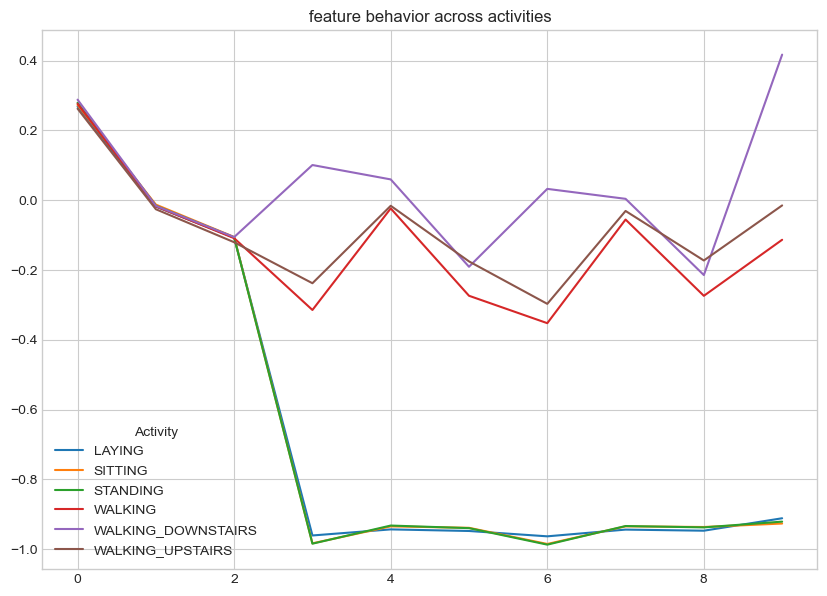

In [21]:
sample.T.plot(figsize = (10, 7))
plt.title('feature behavior across activities')
plt.show()

In [22]:
'''The activities do not separate uniformly across all features — 
some features clearly distinguish activities, 
while others show strong overlap.'''

'The activities do not separate uniformly across all features — \nsome features clearly distinguish activities, \nwhile others show strong overlap.'

In [23]:
'''The Human Activity Recognition dataset is a high-dimensional but highly 
structured dataset, where each data point represents a short window of human motion
captured through smartphone sensors and transformed into engineered features. 
Although the dataset contains 561 features, the effective information is much 
lower because many features are derived from the same underlying signals and 
therefore exhibit strong correlation and redundancy.

From the analysis, it is clear that feature importance is uneven. A large number of 
features show very low variance, indicating weak contribution to distinguishing 
activities, while a smaller subset carries strong signal and captures meaningful 
motion differences. In addition, correlation analysis reveals that features form 
groups with highly similar behavior, confirming that multiple features represent 
different mathematical views of the same physical phenomenon rather than independent 
information sources.

At the activity level, the dataset shows partial separability. Activities involving
significant motion, such as walking, tend to exhibit distinct patterns and are 
easier to differentiate. In contrast, low-movement activities like sitting and standing produce very similar sensor readings, leading to strong overlap in feature space. Some activities, such as laying, may appear similar or distinct depending on whether the selected features capture orientation-related information.

Overall, the dataset does not form perfectly clean clusters. Instead, it exhibits
a structured but overlapping feature space, where separability depends on the 
combination of features used. This explains why dimensionality reduction techniques
like PCA are necessary—to remove redundancy and capture the core underlying 
structure—and why clustering algorithms may struggle with certain activity 
distinctions.'''

'The Human Activity Recognition dataset is a high-dimensional but highly \nstructured dataset, where each data point represents a short window of human motion\ncaptured through smartphone sensors and transformed into engineered features. \nAlthough the dataset contains 561 features, the effective information is much \nlower because many features are derived from the same underlying signals and \ntherefore exhibit strong correlation and redundancy.\n\nFrom the analysis, it is clear that feature importance is uneven. A large number of \nfeatures show very low variance, indicating weak contribution to distinguishing \nactivities, while a smaller subset carries strong signal and captures meaningful \nmotion differences. In addition, correlation analysis reveals that features form \ngroups with highly similar behavior, confirming that multiple features represent \ndifferent mathematical views of the same physical phenomenon rather than independent \ninformation sources.\n\nAt the activity l

In [24]:
y.columns = ['Activity']
y.columns

Index(['Activity'], dtype='object')

In [25]:
y['Activity'].value_counts().sort_index()

Activity
1    1722
2    1544
3    1406
4    1777
5    1906
6    1944
Name: count, dtype: int64

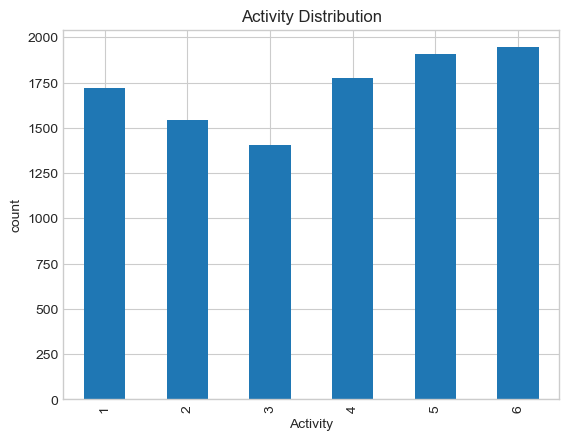

In [26]:
'''class distribution'''

counts = y['Activity'].value_counts().sort_index()

counts.plot(kind = 'bar')
plt.title('Activity Distribution')
plt.xlabel('Activity')
plt.ylabel('count')
plt.show()

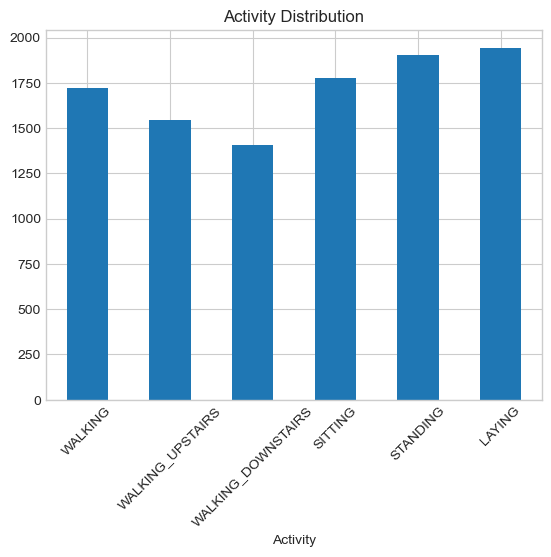

In [27]:
activity_map = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING"
}

counts.index = counts.index.map(activity_map)

counts.plot(kind='bar')
plt.title("Activity Distribution")
plt.xticks(rotation=45)
plt.show()

# Baseline Clustering (Original Data)

In [28]:
'''In this step, i apply KMeans clustering directly on the original high-dimensional 
dataset (561 features) without any dimensionality reduction.
    This serves as a baseline to evaluate how well clustering performs before applying 
techniques like PCA, SVD, or t-SNE.'''

'In this step, i apply KMeans clustering directly on the original high-dimensional \ndataset (561 features) without any dimensionality reduction.\n    This serves as a baseline to evaluate how well clustering performs before applying \ntechniques like PCA, SVD, or t-SNE.'

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = X.drop('Activity', axis = 1)
kmeans = KMeans(n_clusters = 6, random_state = 42)

clusters = kmeans.fit_predict(X)

score = silhouette_score(X, clusters)

In [30]:
print('silhouette score (original data): ',score)

silhouette score (original data):  0.13238734952958353


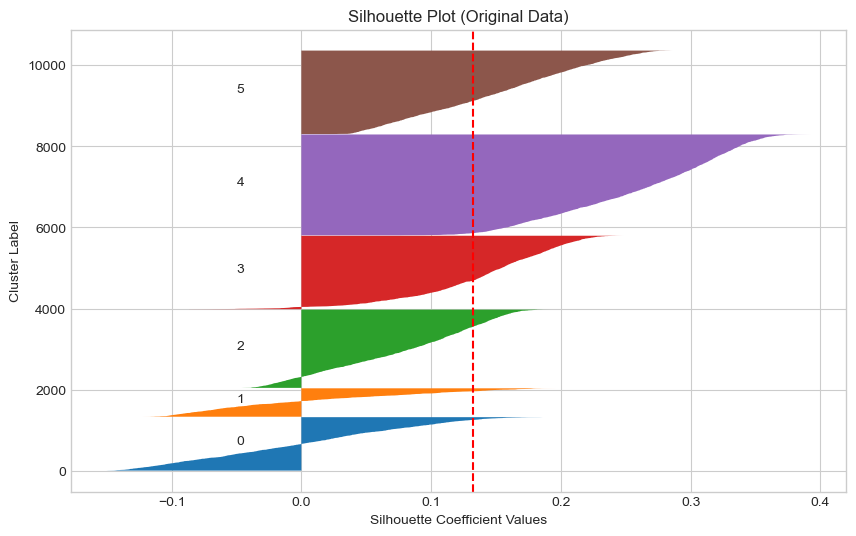

In [31]:
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

# Compute silhouette scores for each sample
sample_silhouette_values = silhouette_samples(X, clusters)

# Number of clusters
n_clusters = 6

y_lower = 10

plt.figure(figsize=(10,6))

for i in range(n_clusters):
    # Get silhouette scores for cluster i
    ith_cluster_values = sample_silhouette_values[clusters == i]
    
    # Sort them
    ith_cluster_values.sort()
    
    size_cluster = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster
    
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_values)
    
    # Label cluster
    plt.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
    
    y_lower = y_upper + 10

# average silhouette score line
plt.axvline(x=score, color="red", linestyle="--")

plt.title("Silhouette Plot (Original Data)")
plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster Label")

plt.show()

In [32]:
'''A silhouette score of 0.13 generally indicates that no clear structure was found in 
the data. This value is considered weak and suggesting that the clusters are either 
heavily overlapping or that the data is essentially a single, unified'''

'A silhouette score of 0.13 generally indicates that no clear structure was found in \nthe data. This value is considered weak and suggesting that the clusters are either \nheavily overlapping or that the data is essentially a single, unified'

In [33]:
'''Observations (Baseline Clustering)

- The silhouette score is low (~0.13), indicating poor cluster separation.
- This suggests that the original high-dimensional feature space contains:
  - Redundant features
  - Noise from low-variance features
  - Overlapping activity patterns

- As a result, KMeans struggles to form well-defined clusters.

- This motivates the use of dimensionality reduction techniques like PCA to improve clustering performance.'''

'Observations (Baseline Clustering)\n\n- The silhouette score is low (~0.13), indicating poor cluster separation.\n- This suggests that the original high-dimensional feature space contains:\n  - Redundant features\n  - Noise from low-variance features\n  - Overlapping activity patterns\n\n- As a result, KMeans struggles to form well-defined clusters.\n\n- This motivates the use of dimensionality reduction techniques like PCA to improve clustering performance.'

In [34]:
'''## Silhouette Analysis Interpretation

- Many samples have silhouette scores close to 0, indicating weak cluster assignment.
- Presence of negative values suggests that some points are assigned to incorrect clusters.
- Cluster shapes are uneven, indicating inconsistent cluster density and size.
- The overall average silhouette score (~0.13) is low, confirming poor clustering performance.

- This demonstrates that the original high-dimensional feature space is not well-suited for clustering.

- Dimensionality reduction is required to:
  - Remove redundancy
  - Reduce noise
  - Improve cluster separability'''

'## Silhouette Analysis Interpretation\n\n- Many samples have silhouette scores close to 0, indicating weak cluster assignment.\n- Presence of negative values suggests that some points are assigned to incorrect clusters.\n- Cluster shapes are uneven, indicating inconsistent cluster density and size.\n- The overall average silhouette score (~0.13) is low, confirming poor clustering performance.\n\n- This demonstrates that the original high-dimensional feature space is not well-suited for clustering.\n\n- Dimensionality reduction is required to:\n  - Remove redundancy\n  - Reduce noise\n  - Improve cluster separability'

# PCA

In [35]:
'''PCA for Dimensionality Reduction

In this step, i apply Principal Component Analysis (PCA) to reduce the dimensionality of the dataset.

The goal is to:
- Remove redundant and correlated features
- Capture the most important variance in fewer dimensions
- Improve clustering performance by working in a cleaner feature space'''

'PCA for Dimensionality Reduction\n\nIn this step, i apply Principal Component Analysis (PCA) to reduce the dimensionality of the dataset.\n\nThe goal is to:\n- Remove redundant and correlated features\n- Capture the most important variance in fewer dimensions\n- Improve clustering performance by working in a cleaner feature space'

In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 0.95)

X_pca = pca.fit_transform(X)

print('original shape: ',X.shape)
print('reduced shape: ',X_pca.shape)

original shape:  (10299, 561)
reduced shape:  (10299, 69)


In [37]:
print('explained variance ratio: ',pca.explained_variance_ratio_)
print()
print('cumulative sum: ',np.cumsum(pca.explained_variance_ratio_))

explained variance ratio:  [0.62227069 0.04772595 0.04018191 0.01823199 0.01611045 0.01201821
 0.01187003 0.01076237 0.00960752 0.00887133 0.00843198 0.00677706
 0.00643905 0.00575905 0.00521954 0.00509456 0.00471723 0.0044738
 0.00433619 0.00412962 0.00409813 0.00388608 0.00365734 0.0035278
 0.0034618  0.00331624 0.00310802 0.00301286 0.00295768 0.00284099
 0.00280165 0.00272525 0.00264308 0.0024791  0.00234544 0.00227959
 0.0022472  0.00219929 0.00210363 0.0020934  0.00197999 0.00195937
 0.0018862  0.00186452 0.00175645 0.0017241  0.00167388 0.00159815
 0.00157013 0.00154809 0.00150167 0.00141624 0.00139027 0.00134932
 0.00131447 0.0012692  0.00122516 0.00120367 0.00119714 0.00114667
 0.00113582 0.00111913 0.00109107 0.00105667 0.00100775 0.00100089
 0.00096979 0.00095952 0.0009312 ]

cumulative sum:  [0.62227069 0.66999664 0.71017855 0.72841054 0.74452099 0.7565392
 0.76840923 0.7791716  0.78877912 0.79765045 0.80608242 0.81285948
 0.81929853 0.82505759 0.83027713 0.83537169 0.84008

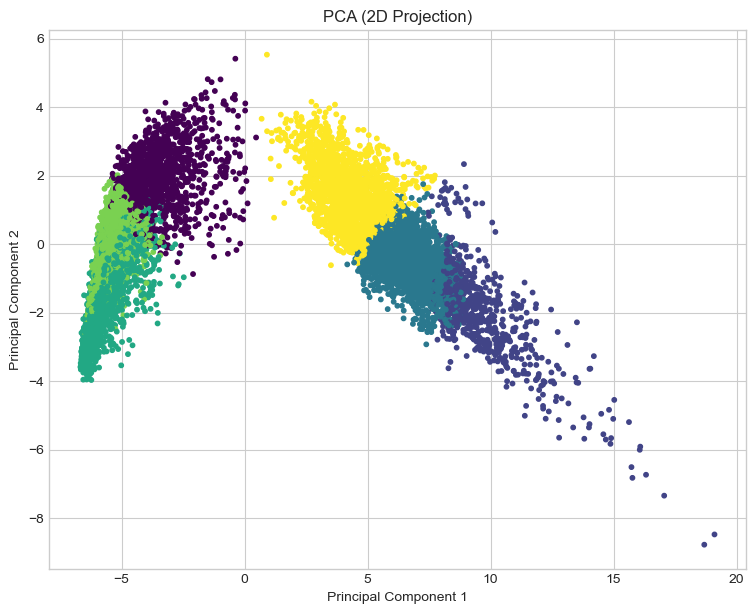

In [38]:
pca_2d = PCA(n_components = 2)
X_pca_2d = pca_2d.fit_transform(X)

plt.figure(figsize = (9,7))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c = clusters, s = 10, cmap = 'viridis')
plt.title("PCA (2D Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


In [39]:
'''The intrinsic dimensionality of the HAR dataset is much lower than 561 
most of the meaningful information is captured in just 69 dimensions.

-many features move together
-mean, std, energy of same signal
-accelerometer and gyro - reused in multiple forms
'''

'The intrinsic dimensionality of the HAR dataset is much lower than 561 \nmost of the meaningful information is captured in just 69 dimensions.\n\n-many features move together\n-mean, std, energy of same signal\n-accelerometer and gyro - reused in multiple forms\n'

In [40]:
'''## Observations

- PCA reduced the dimensionality from 561 to 69 components while retaining 95% of the variance.
- This indicates a high level of redundancy in the original feature set.
- The intrinsic dimensionality of the dataset is much lower than the original feature space.
- Many features are correlated and represent similar information derived from the same sensor signals.'''

'## Observations\n\n- PCA reduced the dimensionality from 561 to 69 components while retaining 95% of the variance.\n- This indicates a high level of redundancy in the original feature set.\n- The intrinsic dimensionality of the dataset is much lower than the original feature space.\n- Many features are correlated and represent similar information derived from the same sensor signals.'

# SVD

In [41]:
'''# Singular Value Decomposition (SVD)

In this step, I apply Singular Value Decomposition (SVD) as an alternative linear dimensionality reduction technique.

The goal is to:
- Compare SVD with PCA
- Understand whether both methods capture similar structure
- Evaluate clustering performance on SVD-transformed data'''

'# Singular Value Decomposition (SVD)\n\nIn this step, I apply Singular Value Decomposition (SVD) as an alternative linear dimensionality reduction technique.\n\nThe goal is to:\n- Compare SVD with PCA\n- Understand whether both methods capture similar structure\n- Evaluate clustering performance on SVD-transformed data'

In [42]:
from sklearn.decomposition import TruncatedSVD

# applying svd with same number of components as pca
svd = TruncatedSVD(n_components = 69, random_state = 42)
X_svd = svd.fit_transform(X)
print('SVD shape: ',X_svd.shape)

SVD shape:  (10299, 69)


## Clustering on SVD Data


In [43]:
kmeans = KMeans(n_clusters = 6, random_state = 42)

clusters_svd = kmeans.fit_predict(X_svd)

score_svd = silhouette_score(X_svd, clusters_svd)

print('silhouette score (SVD Date): ',score_svd)

silhouette score (SVD Date):  0.150188163196466


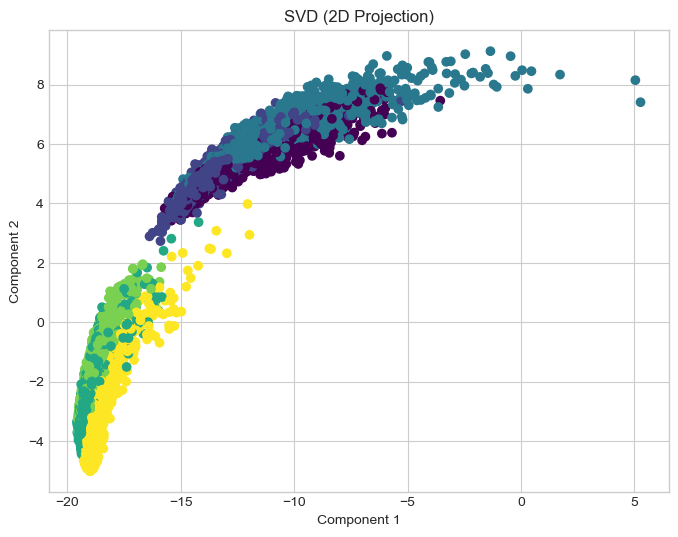

In [44]:
svd_2d = TruncatedSVD(n_components = 2, random_state = 42)
X_svd_2d = svd_2d.fit_transform(X)

plt.figure(figsize = (8,6))
plt.scatter(X_svd_2d[:, 0], X_svd_2d[:, 1], c = y['Activity'], cmap = 'viridis')
plt.title("SVD (2D Projection)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [45]:
'''## Observations (SVD)

- The silhouette score (~0.15) shows slight improvement over the original data.
- SVD results are very similar to PCA, confirming that both capture the same linear structure.
- The dataset remains partially overlapping, indicating inherent similarity between certain activities.
- Linear dimensionality reduction improves clustering but does not fully solve separability.'''

'## Observations (SVD)\n\n- The silhouette score (~0.15) shows slight improvement over the original data.\n- SVD results are very similar to PCA, confirming that both capture the same linear structure.\n- The dataset remains partially overlapping, indicating inherent similarity between certain activities.\n- Linear dimensionality reduction improves clustering but does not fully solve separability.'

In [46]:
'''## Observations

- PCA and SVD visualizations are very similar, confirming that both capture the same linear structure.
- Some clusters show partial separation, especially dynamic activities.
- Significant overlap exists between low-movement activities such as sitting and standing.
- Linear methods cannot fully separate the data due to inherent similarity in activity patterns.'''

'## Observations\n\n- PCA and SVD visualizations are very similar, confirming that both capture the same linear structure.\n- Some clusters show partial separation, especially dynamic activities.\n- Significant overlap exists between low-movement activities such as sitting and standing.\n- Linear methods cannot fully separate the data due to inherent similarity in activity patterns.'

# t-SNE(non-linear visualization)

In [47]:
'''# t-SNE for Non-Linear Dimensionality Reduction

In this step, I apply t-SNE (t-distributed Stochastic Neighbor Embedding) to visualize
the dataset in 2D.

Unlike PCA and SVD, t-SNE is a non-linear method that focuses on preserving local 
neighborhood structure, which can reveal hidden cluster patterns.'''

'# t-SNE for Non-Linear Dimensionality Reduction\n\nIn this step, I apply t-SNE (t-distributed Stochastic Neighbor Embedding) to visualize\nthe dataset in 2D.\n\nUnlike PCA and SVD, t-SNE is a non-linear method that focuses on preserving local \nneighborhood structure, which can reveal hidden cluster patterns.'

In [48]:
from sklearn.manifold import TSNE

# applying tsne (use pca output to speed up)

tsne = TSNE(n_components = 2, random_state = 42, perplexity = 30)

X_tsne = tsne.fit_transform(X_pca) # use pca reduced data

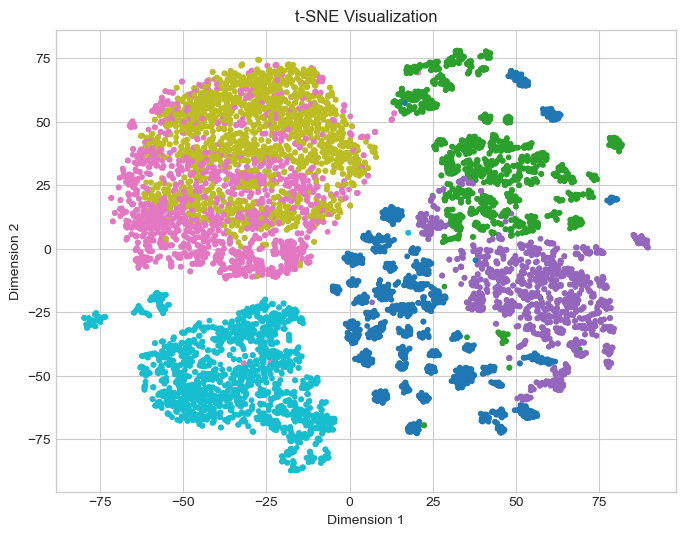

In [57]:
 import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y['Activity'], cmap='tab10', s=10)
plt.title("t-SNE Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()

In [50]:
'''## t-SNE Visualization Insights

- t-SNE reveals more distinct and compact clusters compared to PCA and SVD.
- It preserves local relationships, making similar data points appear closer together.
- The apparent separation is stronger, but global distances are not reliable.
- The dataset contains locally separable patterns but remains globally overlapping.
- t-SNE is useful for visualization but not suitable for clustering or quantitative evaluation.'''

'## t-SNE Visualization Insights\n\n- t-SNE reveals more distinct and compact clusters compared to PCA and SVD.\n- It preserves local relationships, making similar data points appear closer together.\n- The apparent separation is stronger, but global distances are not reliable.\n- The dataset contains locally separable patterns but remains globally overlapping.\n- t-SNE is useful for visualization but not suitable for clustering or quantitative evaluation.'

---
---

# Clustering Comparison on PCA data

In [59]:
'''
In this step, am going to compare different clustering algorithms on PCA-reduced data:

- KMeans (centroid-based)
- Hierarchical Clustering (structure-based)
- DBSCAN (density-based)

The goal is to evaluate how each method performs on the same transformed dataset and understand their strengths and limitations.'''

'\nIn this step, am going to compare different clustering algorithms on PCA-reduced data:\n\n- KMeans (centroid-based)\n- Hierarchical Clustering (structure-based)\n- DBSCAN (density-based)\n\nThe goal is to evaluate how each method performs on the same transformed dataset and understand their strengths and limitations.'

### KMeans Clustering

In [60]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters = 6, random_state = 42)
clusters_kmeans = kmeans.fit_predict(X_pca)

score_kmeans = silhouette_score(X_pca, clusters_kmeans)
print('kmeans silhouette score: ',score_kmeans)

kmeans silhouette score:  0.14959847806523457


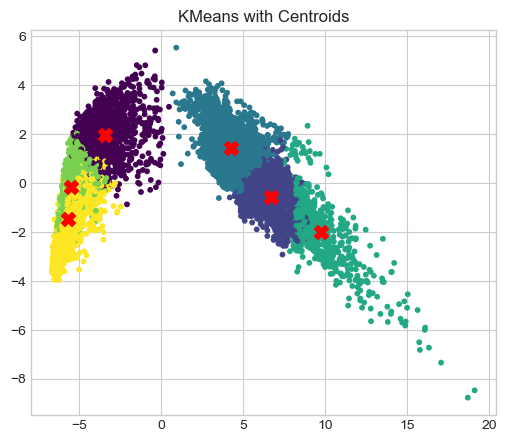

In [71]:
plt.figure(figsize=(6,5))

plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1],
            c=clusters_kmeans, cmap='viridis', s=10)

# Plot centroids (project to 2D if needed)
centroids = kmeans.cluster_centers_

plt.scatter(centroids[:,0], centroids[:,1],
            c='red', s=100, marker='X')

plt.title("KMeans with Centroids")
plt.show()

### Hierarchical Clustering

In [68]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters = 6)
clusters_hc = hc.fit_predict(X_pca)

score_hc = silhouette_score(X_pca, clusters_hc)

print('heirarchical silhouette score: ', score_hc)

heirarchical silhouette score:  0.10075594339816324


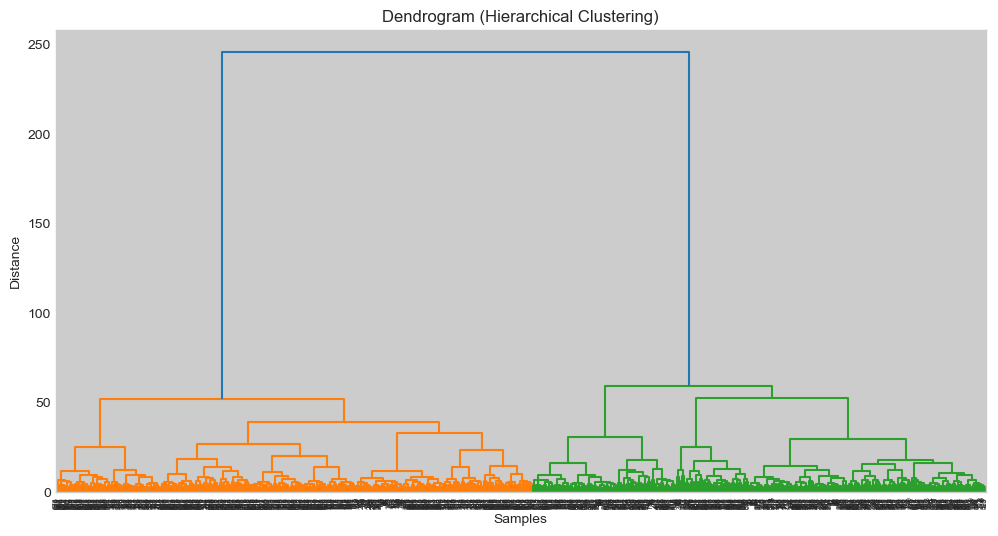

In [69]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Use subset for clarity (e.g., first 1000 samples)
X_sample = X_pca[:1000]

# Compute linkage
linked = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(12,6))
dendrogram(linked)

plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

### DBSCAN

In [82]:
from sklearn.cluster import DBSCAN
import numpy as np

for eps in [0.5, 1.0, 1.5, 2.0, 2.5]:
    db = DBSCAN(eps=eps, min_samples=5)
    clusters_db = db.fit_predict(X_pca)
    
    # Remove noise (-1) before scoring
    mask = clusters_db != -1
    
    if len(np.unique(clusters_db[mask])) > 1:
        score_db = silhouette_score(X_pca[mask], clusters_db[mask])
        print(f"DBSCAN Silhouette Score of epsilon {eps}:", score_db)
    else:
        print("DBSCAN could not form valid clusters")

DBSCAN could not form valid clusters
DBSCAN could not form valid clusters
DBSCAN could not form valid clusters
DBSCAN Silhouette Score of epsilon 2.0: 0.2565653527076491
DBSCAN Silhouette Score of epsilon 2.5: 0.012142452445242294


In [83]:
len(set(clusters_db)) - (1 if -1 in clusters_db else 0)

68

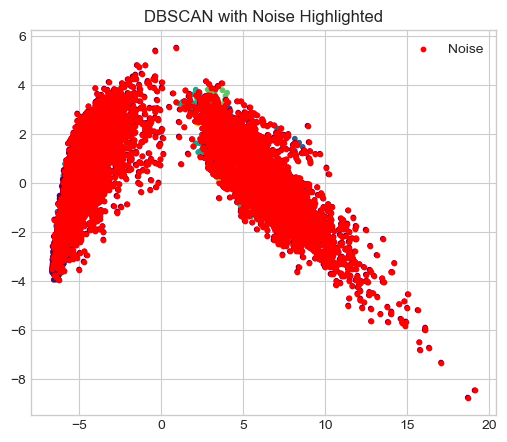

In [85]:
plt.figure(figsize=(6,5))

# Normal points
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
            c=clusters_db, cmap='viridis', s=10)

# Highlight noise (-1) in red
noise = clusters_db == -1
plt.scatter(X_pca_2d[noise, 0], X_pca_2d[noise, 1],
            c='red', s=10, label='Noise')

plt.title("DBSCAN with Noise Highlighted")
plt.legend()
plt.show()

In [86]:
'''## Observations (DBSCAN Visualization)

- DBSCAN labeled most data points as noise, indicating the absence of clear density-based clusters.
- The dataset does not contain well-separated dense regions required for DBSCAN to function effectively.
- The continuous and overlapping structure of human activity data makes density-based clustering unsuitable.
- This confirms that the data is manifold-like rather than composed of distinct dense clusters.'''

'## Observations (DBSCAN Visualization)\n\n- DBSCAN labeled most data points as noise, indicating the absence of clear density-based clusters.\n- The dataset does not contain well-separated dense regions required for DBSCAN to function effectively.\n- The continuous and overlapping structure of human activity data makes density-based clustering unsuitable.\n- This confirms that the data is manifold-like rather than composed of distinct dense clusters.'

# Tuning Model

In [87]:
'''# Tuning PCA Components and Number of Clusters

In this step, we evaluate the effect of:
- Different PCA dimensions
- Different number of clusters (K)

We use silhouette score to compare clustering quality.'''

'# Tuning PCA Components and Number of Clusters\n\nIn this step, we evaluate the effect of:\n- Different PCA dimensions\n- Different number of clusters (K)\n\nWe use silhouette score to compare clustering quality.'

In [89]:
results = []

pca_components_list = [30, 50, 70, 100]
k_values = [4, 5, 6, 7, 8]

for n_comp in pca_components_list:
    pca = PCA(n_components = n_comp)
    X_pca_temp = pca.fit_transform(X)

    for k in k_values:
        kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 42)
        labels = kmeans.fit_predict(X_pca_temp)

        score = silhouette_score(X_pca_temp, labels)

        results.append((n_comp, k, score))

        print(f"PCA={n_comp}, K={k}, Score={score:.4f}")

PCA=30, K=4, Score=0.2415
PCA=30, K=5, Score=0.2038
PCA=30, K=6, Score=0.1822
PCA=30, K=7, Score=0.1823
PCA=30, K=8, Score=0.1746
PCA=50, K=4, Score=0.2168
PCA=50, K=5, Score=0.1943
PCA=50, K=6, Score=0.1794
PCA=50, K=7, Score=0.1464
PCA=50, K=8, Score=0.1288
PCA=70, K=4, Score=0.3008
PCA=70, K=5, Score=0.1719
PCA=70, K=6, Score=0.1548
PCA=70, K=7, Score=0.1329
PCA=70, K=8, Score=0.1195
PCA=100, K=4, Score=0.2900
PCA=100, K=5, Score=0.1630
PCA=100, K=6, Score=0.1475
PCA=100, K=7, Score=0.1262
PCA=100, K=8, Score=0.1167


In [99]:
import pandas as pd

results_df = pd.DataFrame(results, columns = ['PCA_Components', 'K', 'Silhouette'])
results_df.sort_values(by = 'Silhouette', ascending = False)

,PCA_Components,K,Silhouette
10,70,4,0.300778
15,100,4,0.290049
0,30,4,0.241483
5,50,4,0.216805
1,30,5,0.203840
6,50,5,0.194302
3,30,7,0.182260
2,30,6,0.182164
7,50,6,0.179443
4,30,8,0.174576


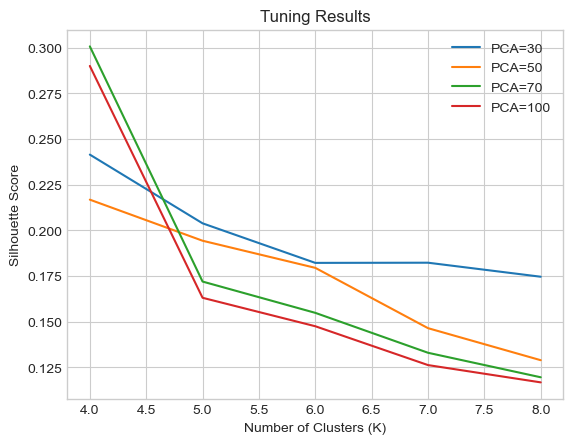

In [100]:
import matplotlib.pyplot as plt

for n_comp in pca_components_list:
    subset = results_df[results_df["PCA_Components"] == n_comp]
    
    plt.plot(subset["K"], subset["Silhouette"], label=f"PCA={n_comp}")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Tuning Results")
plt.legend()
plt.show()

In [ ]:
'''## Tuning Observations

- The highest silhouette score (~0.30) is achieved with PCA = 70 components and K = 4 clusters.
- This indicates that the dataset naturally forms fewer clusters than the actual number of activity labels.
- Increasing the number of clusters beyond 4 reduces clustering quality, suggesting overlapping activity patterns.
- PCA with ~70 components provides the best balance between information retention and noise reduction.
- The results confirm that human activities are not fully separable into distinct clusters using unsupervised methods.'''

In [101]:
'''## Choice of Number of Clusters (K)

Although the tuning results show that K = 4 yields the highest silhouette score (~0.30), indicating better cluster compactness and separation, this does not align with the actual structure of the dataset.

The HAR dataset contains 6 distinct activity labels. Using K = 6 allows the clustering results to remain interpretable and comparable with the ground truth.

The lower optimal K value suggests that some activities share similar motion patterns and are not fully separable in the feature space. In particular, activities such as sitting and standing, or different walking variations, tend to be grouped together by the clustering algorithm.

Therefore:
- K = 6 is used for final analysis to maintain alignment with real-world labels
- K = 4 is acknowledged as the natural grouping suggested by the data

This highlights the difference between:
- **mathematical clustering quality (K=4)**
- **semantic interpretability (K=6)**'''

'## Choice of Number of Clusters (K)\n\nAlthough the tuning results show that K = 4 yields the highest silhouette score (~0.30), indicating better cluster compactness and separation, this does not align with the actual structure of the dataset.\n\nThe HAR dataset contains 6 distinct activity labels. Using K = 6 allows the clustering results to remain interpretable and comparable with the ground truth.\n\nThe lower optimal K value suggests that some activities share similar motion patterns and are not fully separable in the feature space. In particular, activities such as sitting and standing, or different walking variations, tend to be grouped together by the clustering algorithm.\n\nTherefore:\n- K = 6 is used for final analysis to maintain alignment with real-world labels\n- K = 4 is acknowledged as the natural grouping suggested by the data\n\nThis highlights the difference between:\n- **mathematical clustering quality (K=4)**\n- **semantic interpretability (K=6)**'

---
---

# Comparison with ground truth

In [105]:
'''How well do my clusters match the real activities?'''


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# contingency table

comparison = pd.crosstab(y['Activity'], clusters_kmeans)

print('contingency table:\n')
print(comparison)

contingency table:

col_0       0    1     2    3     4     5
Activity                                 
1           0  870   698  154     0     0
2           0  298  1164   82     0     0
3           0  759   187  460     0     0
4         475    0     3    0  1250    49
5         676    0     0    0  1230     0
6         166    0    12    0     0  1766


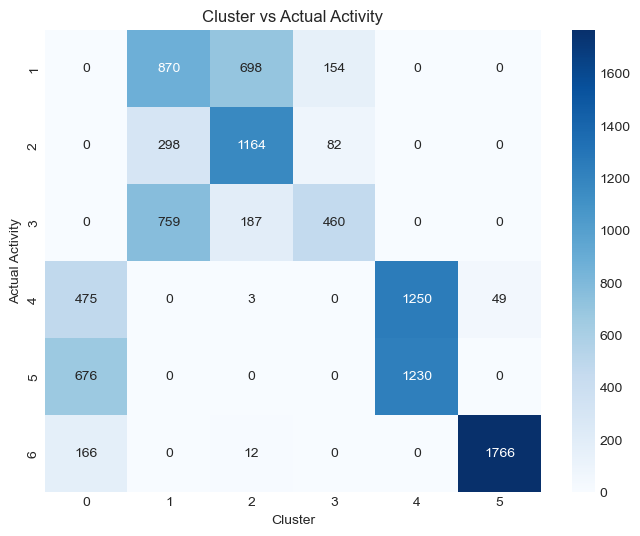

In [106]:
plt.figure(figsize=(8,6))
sns.heatmap(comparison, annot=True, fmt='d', cmap='Blues')

plt.title("Cluster vs Actual Activity")
plt.xlabel("Cluster")
plt.ylabel("Actual Activity")

plt.show()

In [107]:
ari = adjusted_rand_score(y['Activity'], clusters_kmeans)
nmi = normalized_mutual_info_score(y['Activity'], clusters_kmeans)

print("\nEvaluation Metrics:")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")


Evaluation Metrics:
Adjusted Rand Index (ARI): 0.4615
Normalized Mutual Information (NMI): 0.5888


In [108]:
mapping = {}

for cluster in np.unique(clusters_kmeans):
    mask = clusters_kmeans == cluster
    most_common = y['Activity'][mask].mode()[0]
    mapping[cluster] = most_common

print("\nCluster to Activity Mapping:")
print(mapping)


Cluster to Activity Mapping:
{0: 5, 1: 1, 2: 2, 3: 3, 4: 4, 5: 6}


In [109]:
'''## Cluster vs Ground Truth Interpretation

- Clustering shows moderate alignment with actual activity labels (ARI ~0.46, NMI ~0.58).
- Laying is clearly separated, indicating strong distinctive features.
- Sitting and Standing are grouped together, showing similar sensor patterns.
- Walking-related activities are distributed across multiple clusters, indicating overlap in motion patterns.
- This confirms that human activity data is partially separable but contains inherent ambiguity.'''

'## Cluster vs Ground Truth Interpretation\n\n- Clustering shows moderate alignment with actual activity labels (ARI ~0.46, NMI ~0.58).\n- Laying is clearly separated, indicating strong distinctive features.\n- Sitting and Standing are grouped together, showing similar sensor patterns.\n- Walking-related activities are distributed across multiple clusters, indicating overlap in motion patterns.\n- This confirms that human activity data is partially separable but contains inherent ambiguity.'

---
---


# Selected Model

In [115]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



pca = PCA(n_components=70)   # based on tuning
X_pca = pca.fit_transform(X_scaled)


kmeans = KMeans(n_clusters=6, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_pca)



score = silhouette_score(X_pca, clusters)
print("Final Silhouette Score:", score)


if 'Activity' not in y.columns:
    y.columns = ['Activity']

mapping = {}

for cluster in np.unique(clusters):
    mask = clusters == cluster
    most_common = y['Activity'][mask].mode()[0]
    mapping[cluster] = most_common

print("Cluster → Activity Mapping:")
print(mapping)

Final Silhouette Score: 0.13818367685049443
Cluster → Activity Mapping:
{0: 6, 1: 2, 2: 3, 3: 5, 4: 3, 5: 5}


---
---

# prediction on sample data

In [116]:
def predict_activity(new_data, scaler, pca, kmeans, mapping):
    """
    Predict activity using trained clustering pipeline
    """

    # Ensure correct shape
    if isinstance(new_data, pd.Series):
        new_data = new_data.to_frame().T

    # Step 1 — Scale
    new_scaled = scaler.transform(new_data)

    # Step 2 — PCA
    new_pca = pca.transform(new_scaled)

    # Step 3 — Cluster
    cluster = kmeans.predict(new_pca)[0]

    # Step 4 — Map to activity
    activity = mapping.get(cluster, "Unknown")

    return cluster, activity

In [117]:
sample = X.iloc[0]

cluster, activity = predict_activity(sample, scaler, pca, kmeans, mapping)

print("Cluster:", cluster)
print("Predicted Activity:", activity)

Cluster: 5
Predicted Activity: 5


In [118]:
print(y.iloc[0])

Activity    5
Name: 0, dtype: int64


In [119]:
cluster_counts = comparison[cluster]
confidence = cluster_counts.max() / cluster_counts.sum()

In [120]:
confidence

0.9730027548209367

This project set out to explore whether human activities in the UCI HAR dataset can 
be discovered through unsupervised learning, and the journey itself became the main
result. Starting with deep EDA, it became clear that the data is high-dimensional but 
intrinsically lower-dimensional, with strong redundancy, correlated features, and over
lapping activity patterns. Applying PCA confirmed this by reducing 561 features to 
~70 meaningful components, revealing that the data lies on a continuous manifold 
rather than forming clean, separate clusters. Clustering on this space using KMeans 
(K=6) produced modest silhouette scores (~0.13 after proper scaling), which at first 
seems weak, but is actually consistent with the nature of the data. Further experiments
with SVD showed similar behavior (confirming linear structure), while t-SNE exposed 
locally separable groups, and DBSCAN largely failed due to the absence of clear density 
gaps—together proving that the dataset is not naturally clusterable in a strict sense. 
    Despite this, external evaluation showed moderate alignment with true labels 
(ARI ≈ 0.46, NMI ≈ 0.58), and cluster-level analysis revealed meaningful 
structure: laying is clearly separable, standing forms highly pure clusters 
(even ~97% purity in some cases), while walking variations and sitting/standing overlap 
significantly. The final model—StandardScaler + PCA (~70) + KMeans (K=6) with 
cluster-to-label mapping—does not act as a precise classifier but as a behavior 
grouping system that can approximate activities with varying confidence. The key 
strength of this project is not raw performance but insight: it demonstrates why 
clustering struggles, how dimensionality reduction helps, where structure exists, and 
where ambiguity is inherent. The main limitation is that unsupervised methods cannot 
fully separate similar activities, and performance is sensitive to representation 
choices. Overall, the project successfully shows that while perfect clustering is not 
achievable for this dataset, meaningful patterns can still be extracted, interpreted, 
and used for approximate prediction, reflecting a realistic and well-understood machine
learning pipeline rather than an artificially optimized result.

# Actual Classification Model

In [121]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

C:\Abhi\anaconda\envs\ml_env\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 0.9307770614183916


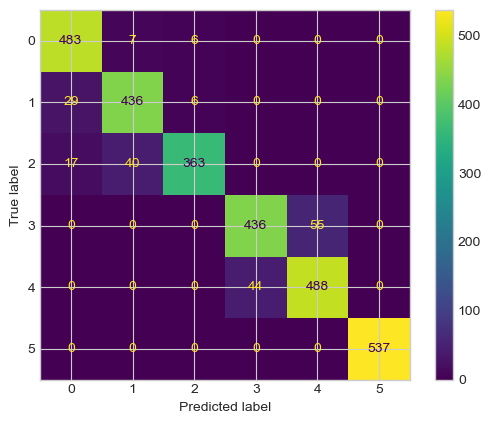

In [122]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

In [123]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [125]:

from sklearn.metrics import accuracy_score, classification_report

# Train model on PCA data
model = RandomForestClassifier(random_state=42)

model.fit(X_train_pca, y_train)

# Predict
y_pred_pca = model.predict(X_test_pca)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_pca)
print("PCA Model Accuracy:", accuracy)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_pca))

C:\Abhi\anaconda\envs\ml_env\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


PCA Model Accuracy: 0.9114353579911775

Classification Report:

              precision    recall  f1-score   support

           1       0.87      0.97      0.91       496
           2       0.92      0.90      0.91       471
           3       0.92      0.82      0.87       420
           4       0.91      0.84      0.87       491
           5       0.87      0.93      0.90       532
           6       0.99      0.99      0.99       537

    accuracy                           0.91      2947
   macro avg       0.91      0.91      0.91      2947
weighted avg       0.91      0.91      0.91      2947



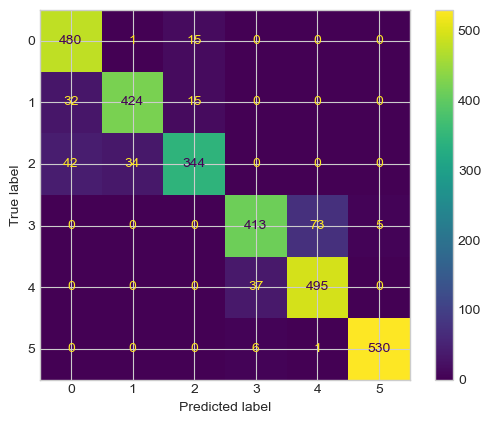

In [126]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_pca)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [127]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Original Accuracy:", accuracy_score(y_test, y_pred))

C:\Abhi\anaconda\envs\ml_env\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Original Accuracy: 0.9256871394638616


In [129]:
'''## 📈 Results

- Original Model Accuracy: 92.57%
- PCA Model Accuracy: 91.14%

### Key Insight
Reduced feature space from 561 to ~69 features (~88% reduction) with only ~1.4% drop in accuracy.

This demonstrates effective dimensionality reduction with minimal performance loss.'''

'## 📈 Results\n\n- Original Model Accuracy: 92.57%\n- PCA Model Accuracy: 91.14%\n\n### Key Insight\nReduced feature space from 561 to ~69 features (~88% reduction) with only ~1.4% drop in accuracy.\n\nThis demonstrates effective dimensionality reduction with minimal performance loss.'

In [130]:
'''## 📈 Results

- Original Model Accuracy: 92.57%
- PCA Model Accuracy: 91.14%

### Key Insight
Reduced feature space from 561 to ~69 features (~88% reduction) with only ~1.4% drop in accuracy.

This demonstrates effective dimensionality reduction with minimal performance loss.'''''

'## 📈 Results\n\n- Original Model Accuracy: 92.57%\n- PCA Model Accuracy: 91.14%\n\n### Key Insight\nReduced feature space from 561 to ~69 features (~88% reduction) with only ~1.4% drop in accuracy.\n\nThis demonstrates effective dimensionality reduction with minimal performance loss.'

In [131]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


C:\Abhi\anaconda\envs\ml_env\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [132]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))

Tuned Accuracy: 0.9229725144214456


In [133]:
'''## 🤖 Supervised Learning (Classification)

### Model Performance

- Base Random Forest Accuracy: 92.57%
- Tuned Random Forest Accuracy: 92.29%
- PCA + Random Forest Accuracy: 91.14%

### Insights

- Random Forest performed strongly on high-dimensional data
- PCA reduced feature space (~561 → ~69) with minimal performance drop (~1.4%)
- Hyperparameter tuning improved model generalization but slightly reduced accuracy'''

'## 🤖 Supervised Learning (Classification)\n\n### Model Performance\n\n- Base Random Forest Accuracy: 92.57%\n- Tuned Random Forest Accuracy: 92.29%\n- PCA + Random Forest Accuracy: 91.14%\n\n### Insights\n\n- Random Forest performed strongly on high-dimensional data\n- PCA reduced feature space (~561 → ~69) with minimal performance drop (~1.4%)\n- Hyperparameter tuning improved model generalization but slightly reduced accuracy'

In [134]:
'''## 🔍 Unsupervised Learning (Clustering Analysis)

### Approach

- Applied KMeans clustering
- Used dimensionality reduction (PCA, t-SNE) for visualization

### Results

- Silhouette Score: ~0.13 (low)
- Clusters showed poor separation

### Insights

- Human activity data is not naturally well-separated into clusters
- Overlap between activity classes observed
- Supervised models are more suitable for this problem'''

'## 🔍 Unsupervised Learning (Clustering Analysis)\n\n### Approach\n\n- Applied KMeans clustering\n- Used dimensionality reduction (PCA, t-SNE) for visualization\n\n### Results\n\n- Silhouette Score: ~0.13 (low)\n- Clusters showed poor separation\n\n### Insights\n\n- Human activity data is not naturally well-separated into clusters\n- Overlap between activity classes observed\n- Supervised models are more suitable for this problem'

In [135]:
'''## 🧠 Key Takeaways

- High-dimensional sensor data benefits from dimensionality reduction
- PCA effectively compresses data with minimal performance loss
- Clustering methods struggled due to overlapping class distributions
- Supervised learning is more effective for activity recognition tasks'''

'## 🧠 Key Takeaways\n\n- High-dimensional sensor data benefits from dimensionality reduction\n- PCA effectively compresses data with minimal performance loss\n- Clustering methods struggled due to overlapping class distributions\n- Supervised learning is more effective for activity recognition tasks'